# 📐 Math & Statistics for AI/ML — Part 1: Foundations

**A comprehensive, from-first-principles guide to the mathematics that powers modern AI and Machine Learning.**

---

## 📑 Table of Contents

| # | Topic | Key Concepts |
|---|-------|-------------|
| 1 | **Probability Fundamentals** | Axioms, Conditional Probability, Bayes' Theorem, Independence |
| 2 | **Probability Distributions** | Bernoulli, Binomial, Gaussian, Poisson, Uniform, Exponential |
| 3 | **Descriptive Statistics** | Mean, Variance, Std Dev, Covariance, Correlation |
| 4 | **Information Theory** | Entropy, Cross-Entropy, KL Divergence |
| 5 | **Loss Functions** | MSE, MAE, Huber, Binary/Categorical Cross-Entropy, Hinge |
| 6 | **Activation Functions** | Sigmoid, Tanh, ReLU, Softmax — with derivatives |
| 7 | **Norms & Regularization** | L1, L2 Norms, Lasso, Ridge, Elastic Net |

---

## 🔧 Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# Color palette
COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4', '#E91E63']
print('✅ Setup complete!')

✅ Setup complete!


---
# 1. 🎲 Probability Fundamentals

Probability is the **language of uncertainty** — and since ML models learn from noisy, incomplete data to make predictions about an uncertain future, probability is the foundational framework upon which everything is built.

---

## 1.1 Core Definitions

| Term | Definition | Example |
|------|-----------|--------|
| **Sample Space** ($\Omega$) | The set of *all* possible outcomes | Rolling a die: $\Omega = \{1,2,3,4,5,6\}$ |
| **Event** ($A$) | A subset of the sample space | Rolling even: $A = \{2,4,6\}$ |
| **Probability** $P(A)$ | A measure $\in [0,1]$ of likelihood | $P(\text{even}) = 3/6 = 0.5$ |

## 1.2 Kolmogorov's Axioms of Probability

Every valid probability measure must satisfy these three axioms:

$$\text{Axiom 1 (Non-negativity):} \quad P(A) \geq 0 \quad \forall A$$

$$\text{Axiom 2 (Normalization):} \quad P(\Omega) = 1$$

$$\text{Axiom 3 (Additivity):} \quad P(A \cup B) = P(A) + P(B) \quad \text{if } A \cap B = \emptyset$$

> **Why it matters in ML:** When a neural network outputs a softmax layer, those outputs must satisfy these axioms — each value $\geq 0$ and they sum to 1. This is what makes them valid probabilities.

## 1.3 Conditional Probability

The probability of event $A$ **given that** event $B$ has occurred:

$$P(A | B) = \frac{P(A \cap B)}{P(B)}, \quad P(B) > 0$$

### Intuition
Once we *know* $B$ happened, our sample space shrinks from $\Omega$ to $B$. We then ask: *"What fraction of $B$ also contains $A$?"*

### Chain Rule (Product Rule)
Rearranging the definition:

$$P(A \cap B) = P(A|B) \cdot P(B) = P(B|A) \cdot P(A)$$

For multiple events:

$$P(A_1, A_2, \ldots, A_n) = P(A_1) \cdot P(A_2|A_1) \cdot P(A_3|A_1,A_2) \cdots P(A_n|A_1,\ldots,A_{n-1})$$

> **ML Connection:** This chain rule is the foundation of **autoregressive language models** (like GPT). They generate text by computing: $P(\text{sentence}) = P(w_1) \cdot P(w_2|w_1) \cdot P(w_3|w_1,w_2) \cdots$

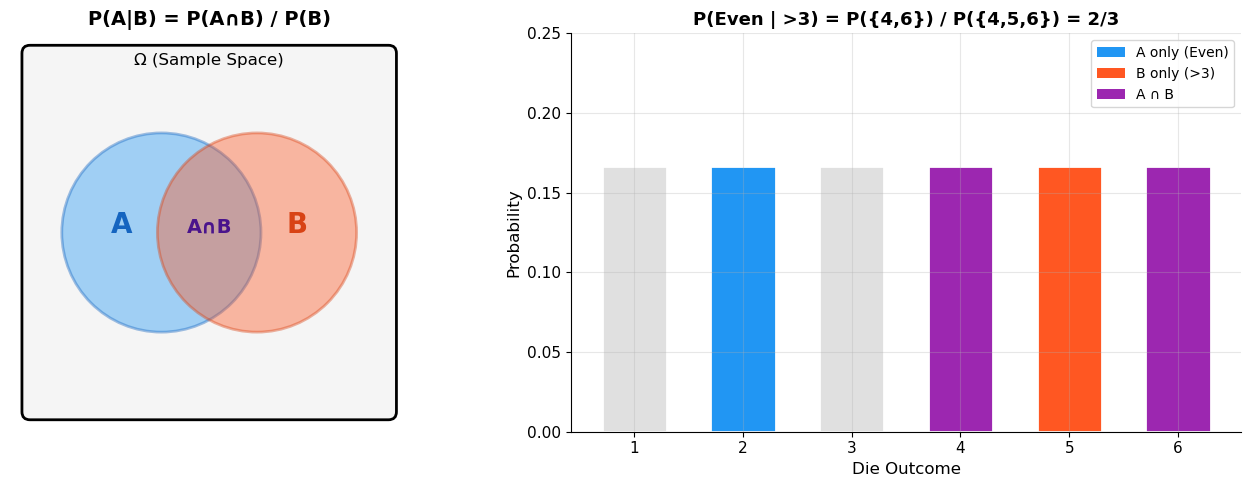

P(A ∩ B) = 2/6 = 0.3333
P(B)     = 3/6 = 0.5000
P(A|B)   = 0.3333 / 0.5000 = 0.6667 = 2/3


In [2]:
# Conditional Probability — Visual Demo
# Example: Medical test with known sensitivity and specificity

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Venn Diagram style ---
ax = axes[0]
from matplotlib.patches import Circle, FancyBboxPatch

# Sample space
rect = FancyBboxPatch((0.05, 0.05), 0.9, 0.9, boxstyle='round,pad=0.02',
                       facecolor='#f5f5f5', edgecolor='black', linewidth=2)
ax.add_patch(rect)

circle_a = Circle((0.38, 0.5), 0.25, facecolor='#2196F3', alpha=0.4, edgecolor='#1565C0', linewidth=2)
circle_b = Circle((0.62, 0.5), 0.25, facecolor='#FF5722', alpha=0.4, edgecolor='#D84315', linewidth=2)
ax.add_patch(circle_a)
ax.add_patch(circle_b)

ax.text(0.28, 0.5, 'A', fontsize=20, fontweight='bold', ha='center', color='#1565C0')
ax.text(0.72, 0.5, 'B', fontsize=20, fontweight='bold', ha='center', color='#D84315')
ax.text(0.5, 0.5, 'A∩B', fontsize=14, fontweight='bold', ha='center', color='#4A148C')
ax.text(0.5, 0.95, 'Ω (Sample Space)', fontsize=12, ha='center', va='top')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.set_title('P(A|B) = P(A∩B) / P(B)', fontsize=14, fontweight='bold')
ax.axis('off')

# --- Right: Numerical example ---
ax = axes[1]
# Fair die example
outcomes = np.arange(1, 7)
A = {2, 4, 6}  # Even numbers
B = {4, 5, 6}  # Greater than 3
A_and_B = A & B  # {4, 6}

colors_bar = ['#2196F3' if x in A and x not in B else
          '#FF5722' if x in B and x not in A else
          '#9C27B0' if x in A_and_B else '#E0E0E0' for x in outcomes]

bars = ax.bar(outcomes, [1/6]*6, color=colors_bar, edgecolor='white', linewidth=2, width=0.6)
ax.set_xlabel('Die Outcome')
ax.set_ylabel('Probability')
ax.set_title('P(Even | >3) = P({4,6}) / P({4,5,6}) = 2/3', fontsize=13, fontweight='bold')
ax.set_xticks(outcomes)
ax.set_ylim(0, 0.25)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='A only (Even)'),
                   Patch(facecolor='#FF5722', label='B only (>3)'),
                   Patch(facecolor='#9C27B0', label='A ∩ B')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# Numerical verification
P_A_and_B = len(A_and_B) / 6
P_B = len(B) / 6
P_A_given_B = P_A_and_B / P_B
print(f'P(A ∩ B) = {len(A_and_B)}/6 = {P_A_and_B:.4f}')
print(f'P(B)     = {len(B)}/6 = {P_B:.4f}')
print(f'P(A|B)   = {P_A_and_B:.4f} / {P_B:.4f} = {P_A_given_B:.4f} = 2/3')

## 1.4 Bayes' Theorem

The **single most important theorem** in probabilistic ML. It lets us **update beliefs** given new evidence.

$$\boxed{P(\theta | D) = \frac{P(D | \theta) \cdot P(\theta)}{P(D)}}$$

| Term | Name | ML Interpretation |
|------|------|-------------------|
| $P(\theta \| D)$ | **Posterior** | Updated belief about parameters after seeing data |
| $P(D \| \theta)$ | **Likelihood** | How probable is the data given these parameters? |
| $P(\theta)$ | **Prior** | Our initial belief before seeing data |
| $P(D)$ | **Evidence** (Marginal Likelihood) | Normalizing constant = $\sum_{\theta} P(D|\theta)P(\theta)$ |

### The Bayesian Workflow in ML

1. **Start** with a prior belief $P(\theta)$ about model parameters
2. **Observe** training data $D$
3. **Compute** the likelihood $P(D|\theta)$ — how well parameters explain the data
4. **Update** to get the posterior $P(\theta|D)$ — refined belief

> **Key insight:** Maximum Likelihood Estimation (MLE) is a *special case* of Bayesian inference where the prior $P(\theta)$ is uniform (we assume all parameter values are equally likely before seeing data).

🏥 Bayesian Medical Test Analysis
Prior P(disease)             = 1.00%
Likelihood P(+|disease)      = 95.00%
False positive P(+|healthy)  = 10.00%
Evidence P(+)                = 0.1085

→ Posterior P(disease|+)      = 8.76%

⚠️  Even with a positive test, there's only a 8.8% chance
   of actually having the disease! The low prior dominates.


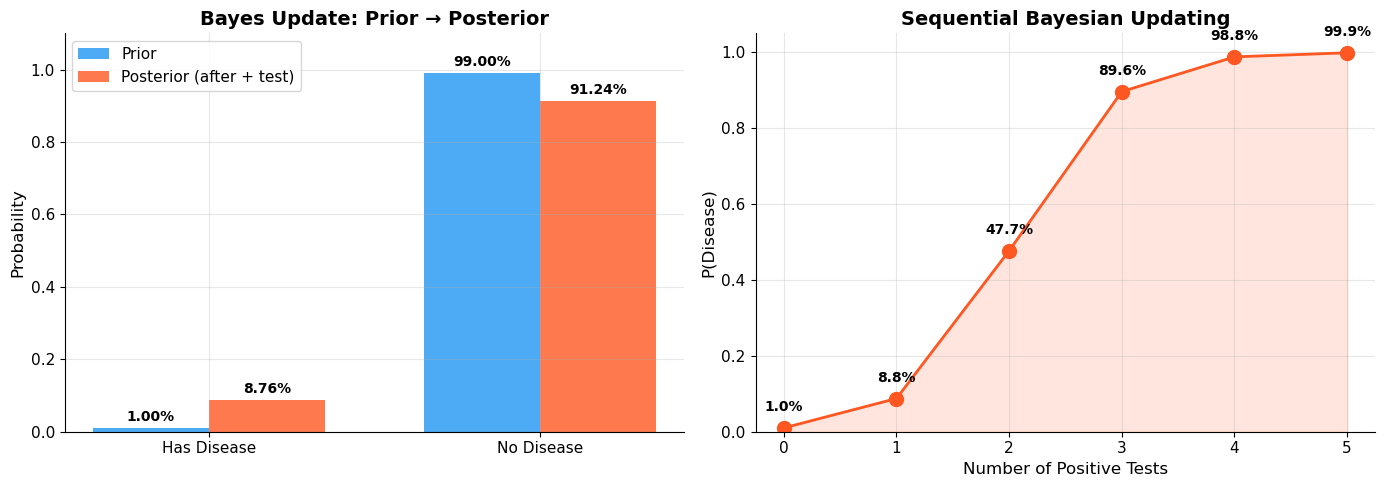

In [3]:
# Bayes' Theorem — Classic Medical Test Example
# A disease affects 1% of the population. A test is 95% sensitive, 90% specific.
# If you test positive, what's the probability you actually have the disease?

P_disease = 0.01        # Prior: prevalence
P_no_disease = 0.99
P_pos_given_disease = 0.95   # Sensitivity (True Positive Rate)
P_pos_given_no_disease = 0.10  # 1 - Specificity (False Positive Rate)

# Evidence: P(positive)
P_pos = P_pos_given_disease * P_disease + P_pos_given_no_disease * P_no_disease

# Posterior: P(disease | positive)
P_disease_given_pos = (P_pos_given_disease * P_disease) / P_pos

print('🏥 Bayesian Medical Test Analysis')
print('=' * 50)
print(f'Prior P(disease)             = {P_disease:.2%}')
print(f'Likelihood P(+|disease)      = {P_pos_given_disease:.2%}')
print(f'False positive P(+|healthy)  = {P_pos_given_no_disease:.2%}')
print(f'Evidence P(+)                = {P_pos:.4f}')
print(f'\n→ Posterior P(disease|+)      = {P_disease_given_pos:.2%}')
print(f'\n⚠️  Even with a positive test, there\'s only a {P_disease_given_pos:.1%} chance')
print(f'   of actually having the disease! The low prior dominates.')

# Visualization: Prior vs Posterior
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
categories = ['Has Disease', 'No Disease']
prior = [P_disease, P_no_disease]
posterior = [P_disease_given_pos, 1 - P_disease_given_pos]

x = np.arange(len(categories))
width = 0.35
axes[0].bar(x - width/2, prior, width, label='Prior', color='#2196F3', alpha=0.8)
axes[0].bar(x + width/2, posterior, width, label='Posterior (after + test)', color='#FF5722', alpha=0.8)
axes[0].set_ylabel('Probability')
axes[0].set_title('Bayes Update: Prior → Posterior', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].legend()
axes[0].set_ylim(0, 1.1)
for i, (p, q) in enumerate(zip(prior, posterior)):
    axes[0].text(i - width/2, p + 0.02, f'{p:.2%}', ha='center', fontsize=10, fontweight='bold')
    axes[0].text(i + width/2, q + 0.02, f'{q:.2%}', ha='center', fontsize=10, fontweight='bold')

# Sequential Bayesian update with multiple tests
ax = axes[1]
n_tests = 5
posterior_history = [P_disease]
current_prior = P_disease
for i in range(n_tests):
    # Each positive test updates the posterior
    p_evidence = P_pos_given_disease * current_prior + P_pos_given_no_disease * (1 - current_prior)
    current_prior = (P_pos_given_disease * current_prior) / p_evidence
    posterior_history.append(current_prior)

ax.plot(range(n_tests + 1), posterior_history, 'o-', color='#FF5722', linewidth=2, markersize=10)
ax.fill_between(range(n_tests + 1), posterior_history, alpha=0.15, color='#FF5722')
ax.set_xlabel('Number of Positive Tests')
ax.set_ylabel('P(Disease)')
ax.set_title('Sequential Bayesian Updating', fontweight='bold')
ax.set_xticks(range(n_tests + 1))
for i, p in enumerate(posterior_history):
    ax.annotate(f'{p:.1%}', (i, p), textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## 1.5 Independence & Conditional Independence

Two events $A$ and $B$ are **independent** if knowing one gives no information about the other:

$$P(A \cap B) = P(A) \cdot P(B) \quad \iff \quad P(A|B) = P(A)$$

**Conditional Independence:** $A$ and $B$ are independent *given* $C$:

$$P(A, B | C) = P(A|C) \cdot P(B|C)$$

> **ML Connection:** The **Naive Bayes** classifier assumes all features are *conditionally independent* given the class label. This is almost never true in practice, but the simplification works surprisingly well because the classifier only needs to get the *ranking* of class probabilities right, not their exact values.

## 1.6 Expectation, Variance & Moments

For a random variable $X$:

### Expectation (Mean)
The "average" outcome, weighted by probability:

$$E[X] = \sum_x x \cdot P(X = x) \qquad \text{(discrete)}$$
$$E[X] = \int_{-\infty}^{\infty} x \cdot f(x) \, dx \qquad \text{(continuous)}$$

**Key properties:**
- Linearity: $E[aX + bY] = aE[X] + bE[Y]$ (always, even if $X,Y$ dependent)
- $E[g(X)] \neq g(E[X])$ in general (Jensen's inequality)

### Variance
How spread out the values are around the mean:

$$\text{Var}(X) = E[(X - E[X])^2] = E[X^2] - (E[X])^2$$

**Key properties:**
- $\text{Var}(aX + b) = a^2 \text{Var}(X)$
- If $X, Y$ independent: $\text{Var}(X + Y) = \text{Var}(X) + \text{Var}(Y)$

### Standard Deviation
$$\sigma = \sqrt{\text{Var}(X)}$$

Same units as $X$ — much more interpretable than variance.

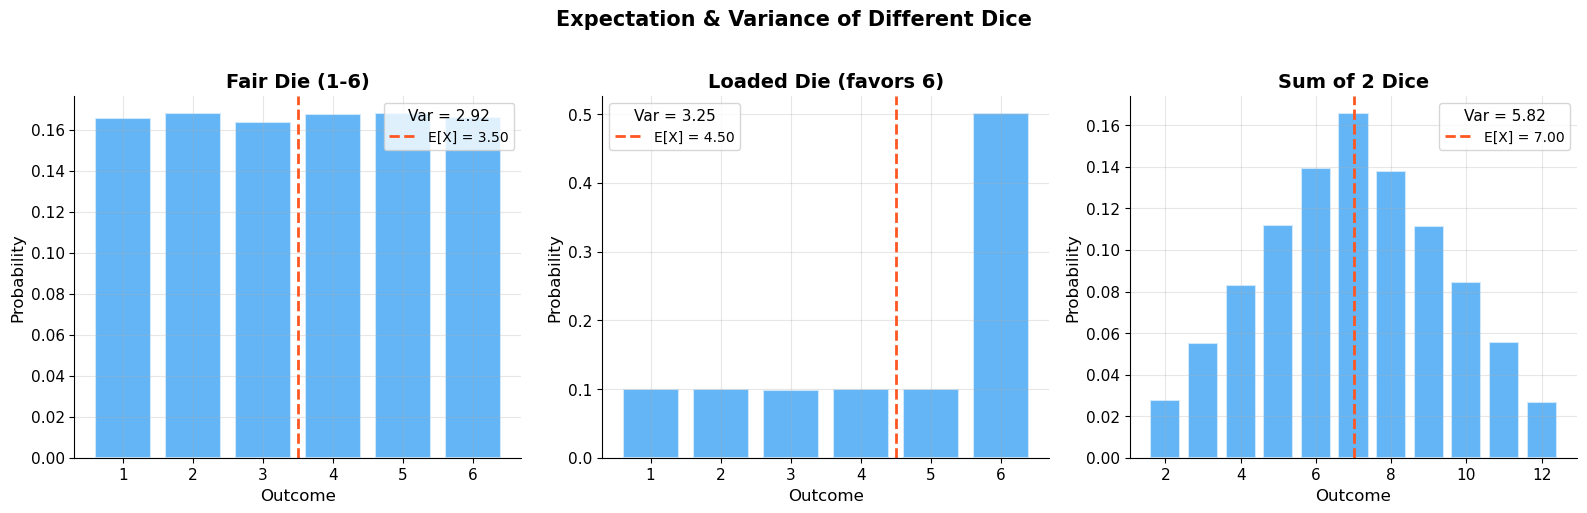

In [4]:
# Expectation & Variance — Demonstration with dice
np.random.seed(42)

# Simulate rolling different types of dice
n_rolls = 100_000
dice = {
    'Fair Die (1-6)': np.random.randint(1, 7, n_rolls),
    'Loaded Die (favors 6)': np.random.choice([1,2,3,4,5,6], n_rolls, p=[0.1,0.1,0.1,0.1,0.1,0.5]),
    'Sum of 2 Dice': np.random.randint(1, 7, n_rolls) + np.random.randint(1, 7, n_rolls),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, rolls) in zip(axes, dice.items()):
    values, counts = np.unique(rolls, return_counts=True)
    probs = counts / n_rolls
    
    ax.bar(values, probs, color=COLORS[0], alpha=0.7, edgecolor='white', linewidth=1.5)
    mean = np.mean(rolls)
    var = np.var(rolls)
    ax.axvline(mean, color='#FF5722', linewidth=2, linestyle='--', label=f'E[X] = {mean:.2f}')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Outcome')
    ax.set_ylabel('Probability')
    ax.legend(title=f'Var = {var:.2f}', fontsize=10)

plt.suptitle('Expectation & Variance of Different Dice', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# 2. 📊 Probability Distributions

A probability distribution describes *how probability is spread* across possible values of a random variable. Choosing the right distribution to model your data is one of the most important decisions in ML.

---

## 2.1 Discrete Distributions

### Bernoulli Distribution
A single trial with two outcomes (success/failure). The simplest distribution.

$$X \sim \text{Bernoulli}(p)$$

$$P(X = k) = p^k (1-p)^{1-k}, \quad k \in \{0, 1\}$$

$$E[X] = p, \qquad \text{Var}(X) = p(1-p)$$

> **ML Usage:** Binary classification output. A logistic regression model outputs $p = \sigma(w^Tx)$, where the label $y \sim \text{Bernoulli}(p)$.

### Binomial Distribution
Number of successes in $n$ independent Bernoulli trials.

$$X \sim \text{Binomial}(n, p)$$

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

$$E[X] = np, \qquad \text{Var}(X) = np(1-p)$$

### Poisson Distribution
Models the number of events in a fixed interval (time, area, etc.) when events occur at a constant average rate.

$$X \sim \text{Poisson}(\lambda)$$

$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$$

$$E[X] = \lambda, \qquad \text{Var}(X) = \lambda$$

> **ML Usage:** Modeling count data — number of clicks, events, word occurrences.

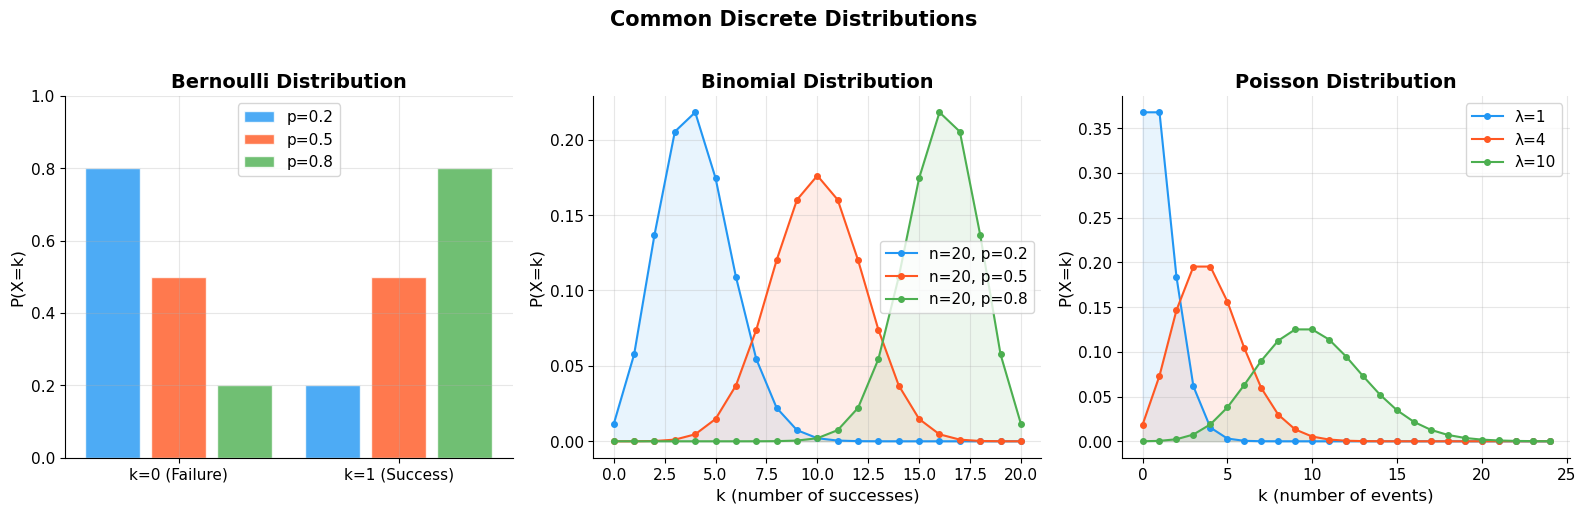

In [5]:
# Discrete Distributions — Visual Comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Bernoulli ---
ax = axes[0]
for i, p in enumerate([0.2, 0.5, 0.8]):
    ax.bar([i*0.3, 1 + i*0.3], [1-p, p], width=0.25, color=COLORS[i],
           alpha=0.8, label=f'p={p}', edgecolor='white')
ax.set_xticks([0.3, 1.3])
ax.set_xticklabels(['k=0 (Failure)', 'k=1 (Success)'])
ax.set_ylabel('P(X=k)')
ax.set_title('Bernoulli Distribution', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)

# --- Binomial ---
ax = axes[1]
n = 20
k = np.arange(0, n+1)
for i, p in enumerate([0.2, 0.5, 0.8]):
    pmf = stats.binom.pmf(k, n, p)
    ax.plot(k, pmf, 'o-', color=COLORS[i], label=f'n={n}, p={p}', markersize=4, linewidth=1.5)
    ax.fill_between(k, pmf, alpha=0.1, color=COLORS[i])
ax.set_xlabel('k (number of successes)')
ax.set_ylabel('P(X=k)')
ax.set_title('Binomial Distribution', fontweight='bold')
ax.legend()

# --- Poisson ---
ax = axes[2]
k = np.arange(0, 25)
for i, lam in enumerate([1, 4, 10]):
    pmf = stats.poisson.pmf(k, lam)
    ax.plot(k, pmf, 'o-', color=COLORS[i], label=f'λ={lam}', markersize=4, linewidth=1.5)
    ax.fill_between(k, pmf, alpha=0.1, color=COLORS[i])
ax.set_xlabel('k (number of events)')
ax.set_ylabel('P(X=k)')
ax.set_title('Poisson Distribution', fontweight='bold')
ax.legend()

plt.suptitle('Common Discrete Distributions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2.2 Continuous Distributions

### Uniform Distribution
All values in $[a, b]$ are equally likely.

$$X \sim \text{Uniform}(a, b)$$

$$f(x) = \frac{1}{b-a}, \quad a \leq x \leq b$$

$$E[X] = \frac{a+b}{2}, \qquad \text{Var}(X) = \frac{(b-a)^2}{12}$$

> **ML Usage:** Random weight initialization, random sampling, random search for hyperparameters.

### Gaussian (Normal) Distribution — ⭐ The Most Important

$$X \sim \mathcal{N}(\mu, \sigma^2)$$

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

$$E[X] = \mu, \qquad \text{Var}(X) = \sigma^2$$

**Why is it everywhere?**
- **Central Limit Theorem:** The sum of many independent random variables tends toward a Gaussian, regardless of their individual distributions
- **Maximum Entropy:** Among all distributions with a given mean and variance, the Gaussian has the *highest entropy* (least assumptions)
- **Noise Model:** Gaussian noise is the default assumption in regression (MSE loss is derived from it!)

### Exponential Distribution
Time between events in a Poisson process.

$$X \sim \text{Exponential}(\lambda)$$

$$f(x) = \lambda e^{-\lambda x}, \quad x \geq 0$$

$$E[X] = \frac{1}{\lambda}, \qquad \text{Var}(X) = \frac{1}{\lambda^2}$$

> **ML Usage:** Modeling wait times, survival analysis, inter-arrival times.

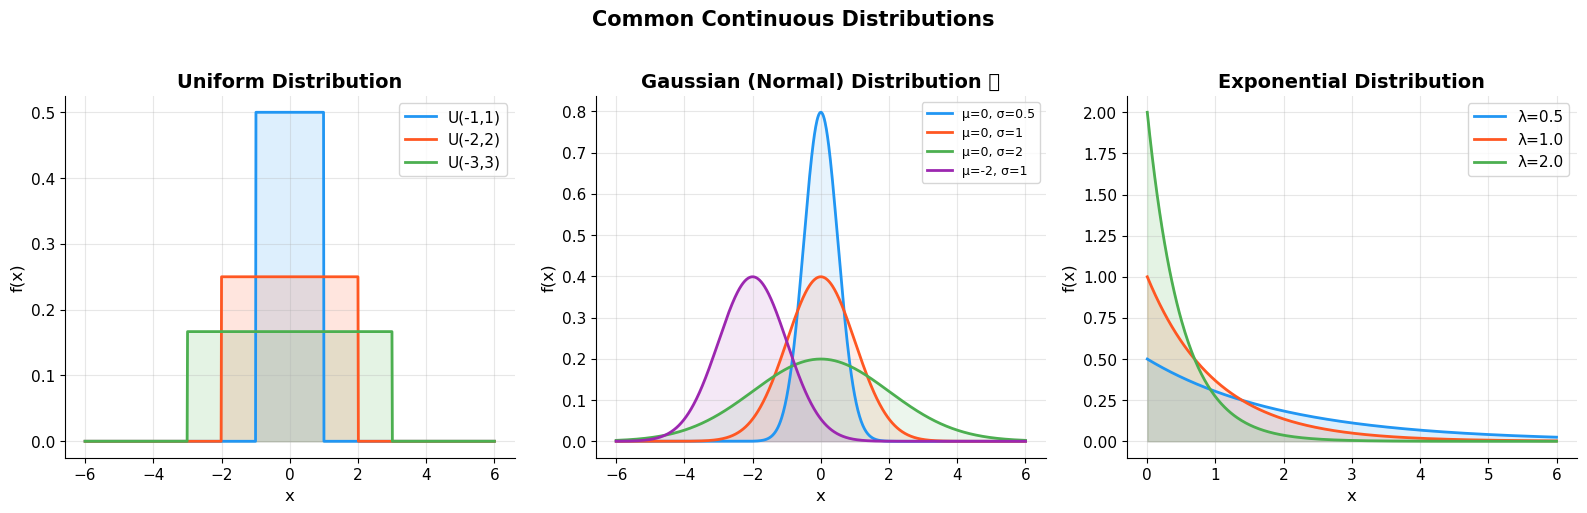

In [6]:
# Continuous Distributions — Visual Exploration
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.linspace(-6, 6, 1000)

# --- Uniform ---
ax = axes[0]
for i, (a, b) in enumerate([(-1, 1), (-2, 2), (-3, 3)]):
    pdf = stats.uniform.pdf(x, a, b - a)
    ax.plot(x, pdf, linewidth=2, color=COLORS[i], label=f'U({a},{b})')
    ax.fill_between(x, pdf, alpha=0.15, color=COLORS[i])
ax.set_title('Uniform Distribution', fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.legend()

# --- Gaussian ---
ax = axes[1]
params = [(0, 0.5), (0, 1), (0, 2), (-2, 1)]
for i, (mu, sigma) in enumerate(params):
    pdf = stats.norm.pdf(x, mu, sigma)
    ax.plot(x, pdf, linewidth=2, color=COLORS[i], label=f'μ={mu}, σ={sigma}')
    ax.fill_between(x, pdf, alpha=0.1, color=COLORS[i])
ax.set_title('Gaussian (Normal) Distribution ⭐', fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.legend(fontsize=9)

# --- Exponential ---
ax = axes[2]
x_exp = np.linspace(0, 6, 500)
for i, lam in enumerate([0.5, 1.0, 2.0]):
    pdf = stats.expon.pdf(x_exp, scale=1/lam)
    ax.plot(x_exp, pdf, linewidth=2, color=COLORS[i], label=f'λ={lam}')
    ax.fill_between(x_exp, pdf, alpha=0.15, color=COLORS[i])
ax.set_title('Exponential Distribution', fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.legend()

plt.suptitle('Common Continuous Distributions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2.3 The Central Limit Theorem (CLT)

One of the most powerful theorems in all of statistics:

> The sum (or mean) of $n$ independent, identically distributed (i.i.d.) random variables, regardless of their original distribution, approaches a **Normal distribution** as $n \to \infty$.

$$\bar{X}_n = \frac{1}{n}\sum_{i=1}^{n} X_i \xrightarrow{d} \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right)$$

Or equivalently, the standardized version:

$$Z_n = \frac{\bar{X}_n - \mu}{\sigma / \sqrt{n}} \xrightarrow{d} \mathcal{N}(0, 1)$$

**Why this matters for ML:**
- Justifies using Gaussian assumptions for many quantities (gradients, parameter estimates)
- Foundation for confidence intervals and hypothesis testing
- Explains why batch normalization works — normalized mini-batch statistics become more Gaussian

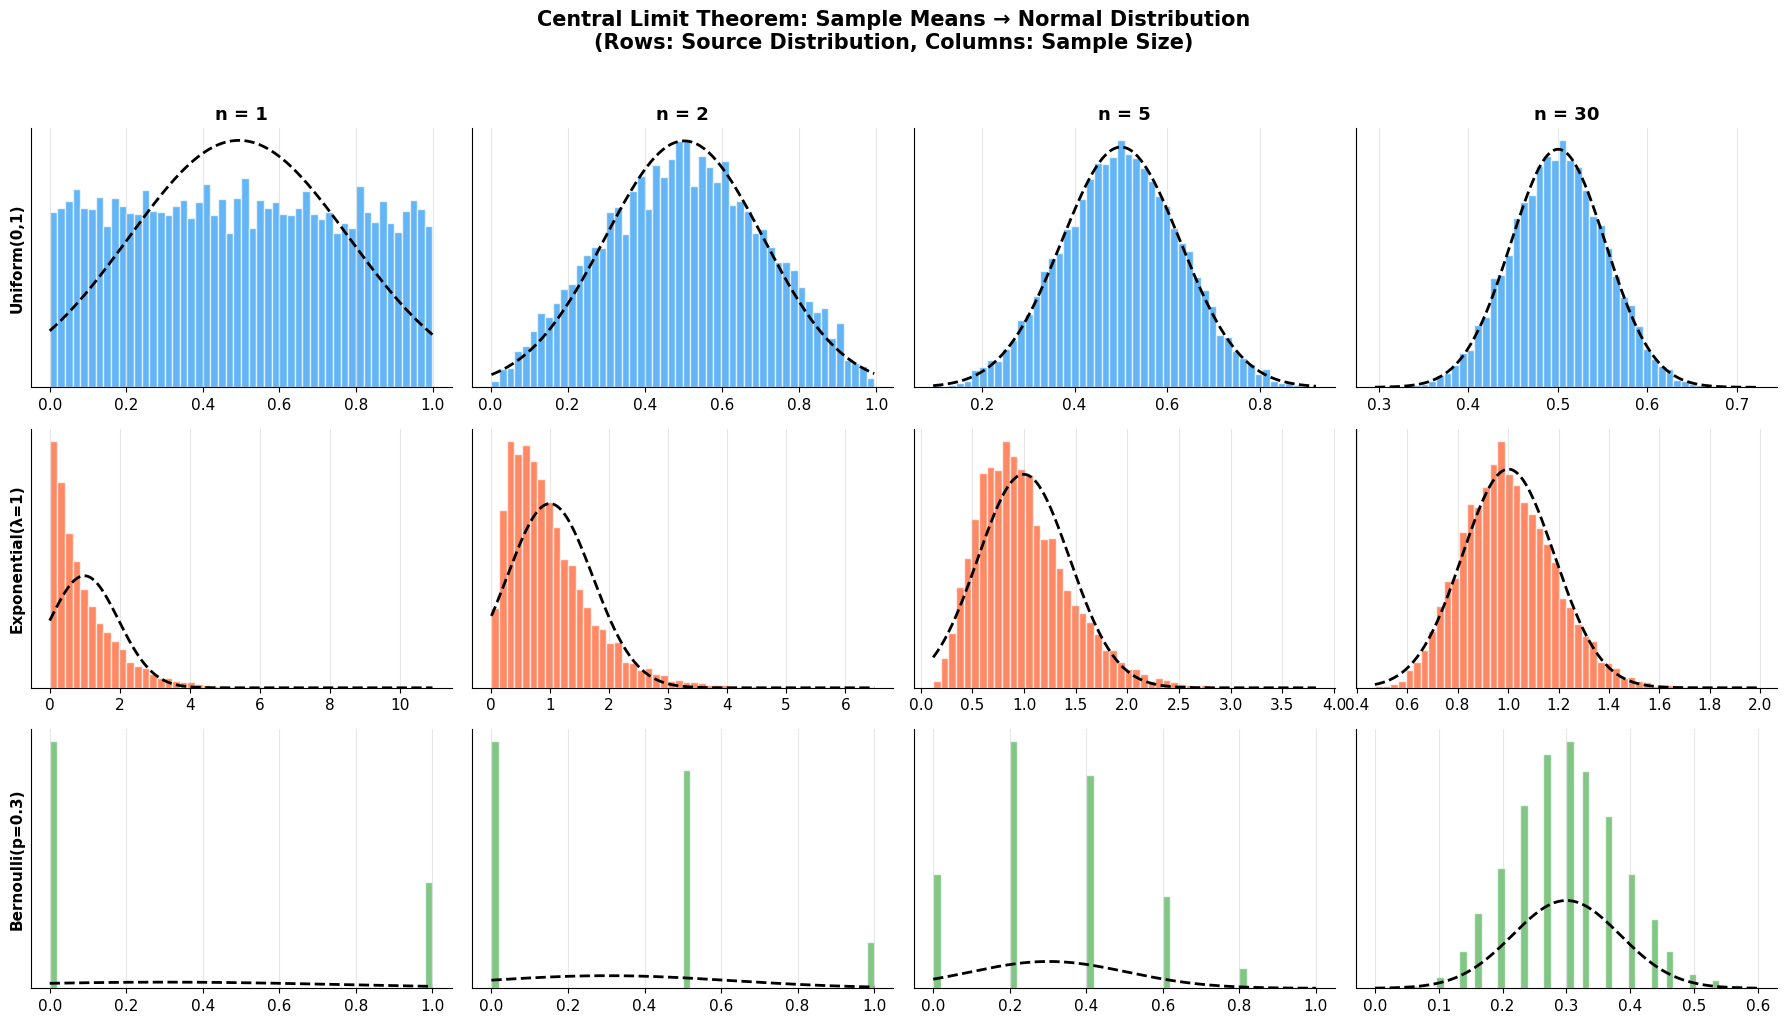

In [7]:
# Central Limit Theorem — Watch it happen!
np.random.seed(42)

# We'll take means of samples from very NON-Gaussian distributions
distributions = {
    'Uniform(0,1)': lambda n: np.random.uniform(0, 1, n),
    'Exponential(λ=1)': lambda n: np.random.exponential(1, n),
    'Bernoulli(p=0.3)': lambda n: np.random.binomial(1, 0.3, n),
}

sample_sizes = [1, 2, 5, 30]
n_experiments = 10_000

fig, axes = plt.subplots(len(distributions), len(sample_sizes), figsize=(18, 10))

for row, (dist_name, sampler) in enumerate(distributions.items()):
    for col, n in enumerate(sample_sizes):
        ax = axes[row][col]
        # Take n_experiments samples of size n, compute mean of each
        means = [np.mean(sampler(n)) for _ in range(n_experiments)]
        
        ax.hist(means, bins=50, density=True, color=COLORS[row], alpha=0.7, edgecolor='white')
        
        # Overlay the theoretical normal
        x_range = np.linspace(min(means), max(means), 200)
        ax.plot(x_range, stats.norm.pdf(x_range, np.mean(means), np.std(means)),
                'k--', linewidth=2, label='Normal fit')
        
        if row == 0:
            ax.set_title(f'n = {n}', fontsize=13, fontweight='bold')
        if col == 0:
            ax.set_ylabel(dist_name, fontsize=11, fontweight='bold')
        ax.set_yticks([])

plt.suptitle('Central Limit Theorem: Sample Means → Normal Distribution\n'
             '(Rows: Source Distribution, Columns: Sample Size)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# 3. 📈 Descriptive Statistics

These are the tools for **summarizing** and **understanding** your data before modeling.

---

## 3.1 Measures of Central Tendency

| Measure | Formula | Robustness | When to Use |
|---------|---------|-----------|------------|
| **Mean** | $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$ | Sensitive to outliers | Symmetric data, no outliers |
| **Median** | Middle value when sorted | Robust to outliers | Skewed data, with outliers |
| **Mode** | Most frequent value | Very robust | Categorical data, multimodal |

## 3.2 Measures of Spread

| Measure | Formula | Notes |
|---------|---------|-------|
| **Variance** | $\sigma^2 = \frac{1}{n}\sum(x_i - \bar{x})^2$ | Average squared deviation from mean |
| **Std Dev** | $\sigma = \sqrt{\sigma^2}$ | Same units as data |
| **Sample Variance** | $s^2 = \frac{1}{n-1}\sum(x_i - \bar{x})^2$ | Bessel's correction for unbiased estimate |
| **IQR** | $Q_3 - Q_1$ | Robust spread measure |

> **Why $n-1$?** (Bessel's Correction) When estimating variance from a sample, using $n$ underestimates the true variance because the sample mean is "closer" to the data points than the true population mean. Dividing by $n-1$ corrects this bias.

## 3.3 Covariance & Correlation

These measure the **linear relationship** between two variables.

### Covariance
$$\text{Cov}(X, Y) = E[(X - E[X])(Y - E[Y])] = E[XY] - E[X]E[Y]$$

- $\text{Cov}(X,Y) > 0$: $X$ and $Y$ tend to increase together
- $\text{Cov}(X,Y) < 0$: When $X$ increases, $Y$ tends to decrease
- $\text{Cov}(X,Y) = 0$: No *linear* relationship (but could be nonlinear!)

**Problem:** Covariance depends on the scale of $X$ and $Y$.

### Pearson Correlation Coefficient
Normalized covariance — always in $[-1, 1]$:

$$\rho(X, Y) = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y}$$

| $\rho$ Value | Interpretation |
|-------------|---------------|
| $+1$ | Perfect positive linear relationship |
| $0$ | No linear relationship |
| $-1$ | Perfect negative linear relationship |

> **⚠️ Correlation ≠ Causation**, and $\rho = 0$ does NOT mean independence! Anscombe's quartet demonstrates this beautifully.

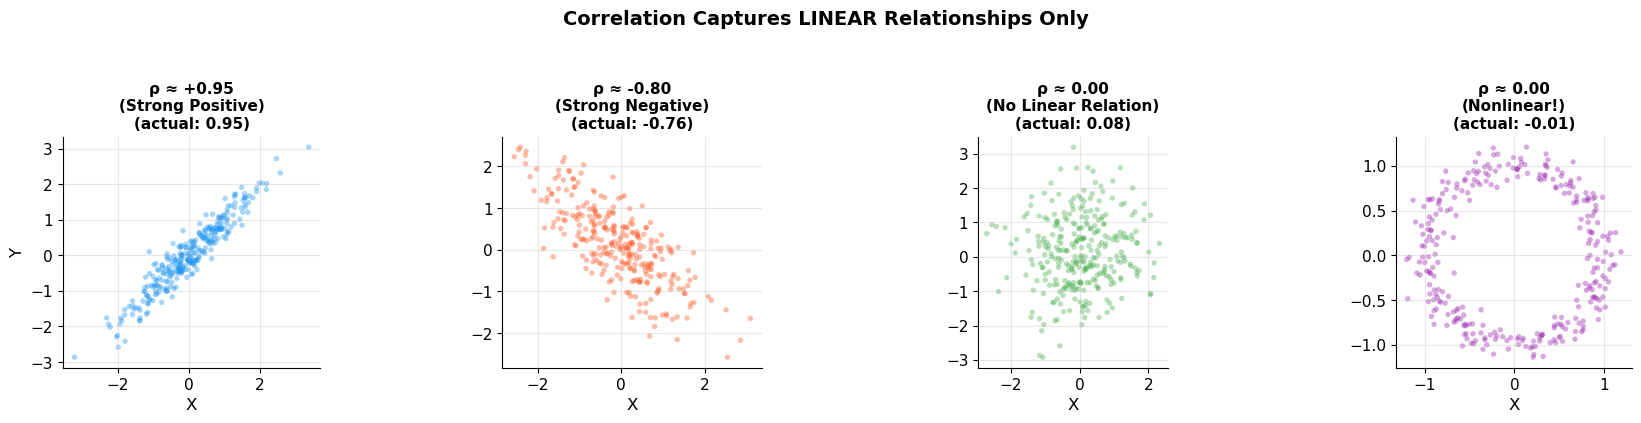

⚠️  The circle (far right) has near-zero correlation despite a clear pattern!
   Correlation only measures LINEAR association.


In [8]:
# Covariance & Correlation — Visual Guide
np.random.seed(42)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Generate datasets with different correlations
n = 300
datasets = [
    ('ρ ≈ +0.95\n(Strong Positive)', np.random.multivariate_normal([0,0], [[1,0.95],[0.95,1]], n)),
    ('ρ ≈ -0.80\n(Strong Negative)', np.random.multivariate_normal([0,0], [[1,-0.8],[-0.8,1]], n)),
    ('ρ ≈ 0.00\n(No Linear Relation)', np.random.multivariate_normal([0,0], [[1,0],[0,1]], n)),
    ('ρ ≈ 0.00\n(Nonlinear!)', None),  # Will create manually
]

# Create the nonlinear dataset
t = np.linspace(0, 2*np.pi, n)
x_circle = np.cos(t) + np.random.normal(0, 0.1, n)
y_circle = np.sin(t) + np.random.normal(0, 0.1, n)

colors_scatter = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

for i, (title, data) in enumerate(datasets):
    ax = axes[i]
    if data is not None:
        x, y = data[:, 0], data[:, 1]
    else:
        x, y = x_circle, y_circle
    
    ax.scatter(x, y, alpha=0.4, s=15, color=colors_scatter[i], edgecolors='none')
    
    # Compute actual correlation
    rho = np.corrcoef(x, y)[0, 1]
    ax.set_title(f'{title}\n(actual: {rho:.2f})', fontweight='bold', fontsize=11)
    ax.set_xlabel('X')
    if i == 0:
        ax.set_ylabel('Y')
    ax.set_aspect('equal')

plt.suptitle('Correlation Captures LINEAR Relationships Only', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print('⚠️  The circle (far right) has near-zero correlation despite a clear pattern!')
print('   Correlation only measures LINEAR association.')

---
# 4. 🔐 Information Theory

Founded by **Claude Shannon** (1948), information theory gives us a mathematical framework for measuring **uncertainty**, **surprise**, and **information content**. It's deeply connected to ML through loss functions.

---

## 4.1 Information Content (Surprisal)

How "surprising" is an event? Rare events carry more information.

$$I(x) = -\log_2 P(x) \quad \text{(in bits)}$$

| Event | Probability | Surprisal |
|-------|-----------|----------|
| Coin lands heads | 0.5 | 1 bit |
| Rolling a 6 | 1/6 | 2.58 bits |
| Rare disease | 0.001 | 9.97 bits |
| Certain event | 1.0 | 0 bits |

## 4.2 Entropy

The **average surprisal** — measures the *inherent uncertainty* of a distribution.

$$H(X) = -\sum_{x} P(x) \log P(x) = E[-\log P(X)]$$

**Key properties:**
- $H(X) \geq 0$ always
- $H(X) = 0$ only when outcome is certain (one $P(x) = 1$, rest are 0)
- For discrete $X$ with $k$ outcomes: $H(X) \leq \log k$ (maximum at uniform distribution)

> **ML Intuition:** A model with high entropy predictions is *uncertain* (outputs near uniform). A model with low entropy is *confident* (outputs peaked on one class).

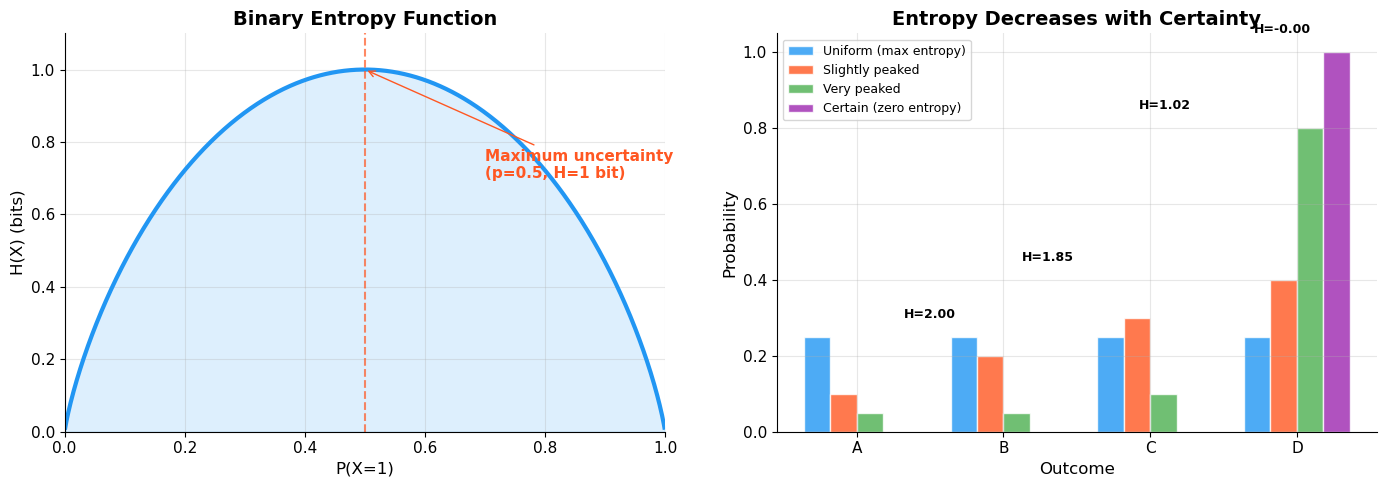

In [9]:
# Entropy — Interactive Visualization for Binary Variable
p_values = np.linspace(0.001, 0.999, 1000)

# Binary entropy: H(p) = -p*log(p) - (1-p)*log(1-p)
entropy_binary = -p_values * np.log2(p_values) - (1 - p_values) * np.log2(1 - p_values)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Binary Entropy Curve ---
ax = axes[0]
ax.plot(p_values, entropy_binary, linewidth=3, color=COLORS[0])
ax.fill_between(p_values, entropy_binary, alpha=0.15, color=COLORS[0])
ax.axvline(0.5, color='#FF5722', linestyle='--', linewidth=1.5, alpha=0.7)
ax.annotate('Maximum uncertainty\n(p=0.5, H=1 bit)', xy=(0.5, 1), xytext=(0.7, 0.7),
            arrowprops=dict(arrowstyle='->', color='#FF5722'),
            fontsize=11, color='#FF5722', fontweight='bold')
ax.set_xlabel('P(X=1)', fontsize=12)
ax.set_ylabel('H(X) (bits)', fontsize=12)
ax.set_title('Binary Entropy Function', fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.1)

# --- Right: Entropy for different distribution shapes ---
ax = axes[1]
distributions_info = [
    ('Uniform (max entropy)', [0.25, 0.25, 0.25, 0.25]),
    ('Slightly peaked', [0.1, 0.2, 0.3, 0.4]),
    ('Very peaked', [0.05, 0.05, 0.1, 0.8]),
    ('Certain (zero entropy)', [0.0, 0.0, 0.0, 1.0]),
]

x_pos = np.arange(4)
width = 0.18
for i, (name, probs) in enumerate(distributions_info):
    offset = (i - 1.5) * width
    bars = ax.bar(x_pos + offset, probs, width, label=name, color=COLORS[i], alpha=0.8, edgecolor='white')
    
    # Compute entropy
    probs_arr = np.array(probs)
    probs_arr = probs_arr[probs_arr > 0]  # avoid log(0)
    H = -np.sum(probs_arr * np.log2(probs_arr))
    ax.text(0.5 + i * 0.8, max(probs) + 0.05, f'H={H:.2f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Outcome')
ax.set_ylabel('Probability')
ax.set_title('Entropy Decreases with Certainty', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(['A', 'B', 'C', 'D'])
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

## 4.3 Cross-Entropy

Measures the average number of bits needed to encode data from distribution $P$ using a code optimized for distribution $Q$:

$$H(P, Q) = -\sum_{x} P(x) \log Q(x) = E_{x \sim P}[-\log Q(x)]$$

**Key relationship:**
$$H(P, Q) = H(P) + D_{KL}(P \| Q)$$

Since $D_{KL} \geq 0$, we always have $H(P, Q) \geq H(P)$.

> **ML Connection:** This is THE loss function for classification! $P$ is the true label distribution (one-hot), $Q$ is the model's predicted distribution (softmax output). **Minimizing cross-entropy = making $Q$ match $P$.**

## 4.4 KL Divergence (Kullback-Leibler)

Measures how "different" distribution $Q$ is from distribution $P$. Also called **relative entropy**.

$$D_{KL}(P \| Q) = \sum_{x} P(x) \log \frac{P(x)}{Q(x)} = E_{x \sim P}\left[\log \frac{P(x)}{Q(x)}\right]$$

**Key properties:**
- $D_{KL}(P \| Q) \geq 0$ always (Gibbs' inequality)
- $D_{KL}(P \| Q) = 0$ if and only if $P = Q$
- **NOT symmetric:** $D_{KL}(P \| Q) \neq D_{KL}(Q \| P)$ in general
- Not a true metric (violates triangle inequality and symmetry)

### Forward vs Reverse KL

| | Forward KL: $D_{KL}(P \| Q)$ | Reverse KL: $D_{KL}(Q \| P)$ |
|---|---|---|
| **Optimizes** | Mean-seeking | Mode-seeking |
| **Behavior** | $Q$ spreads to cover all of $P$ | $Q$ focuses on peaks of $P$ |
| **Used in** | Variational inference (ELBO) | Policy optimization, GANs |
| **Penalty** | High when $P(x) > 0$ but $Q(x) \approx 0$ | High when $Q(x) > 0$ but $P(x) \approx 0$ |

AttributeError: module 'numpy' has no attribute 'trapz'

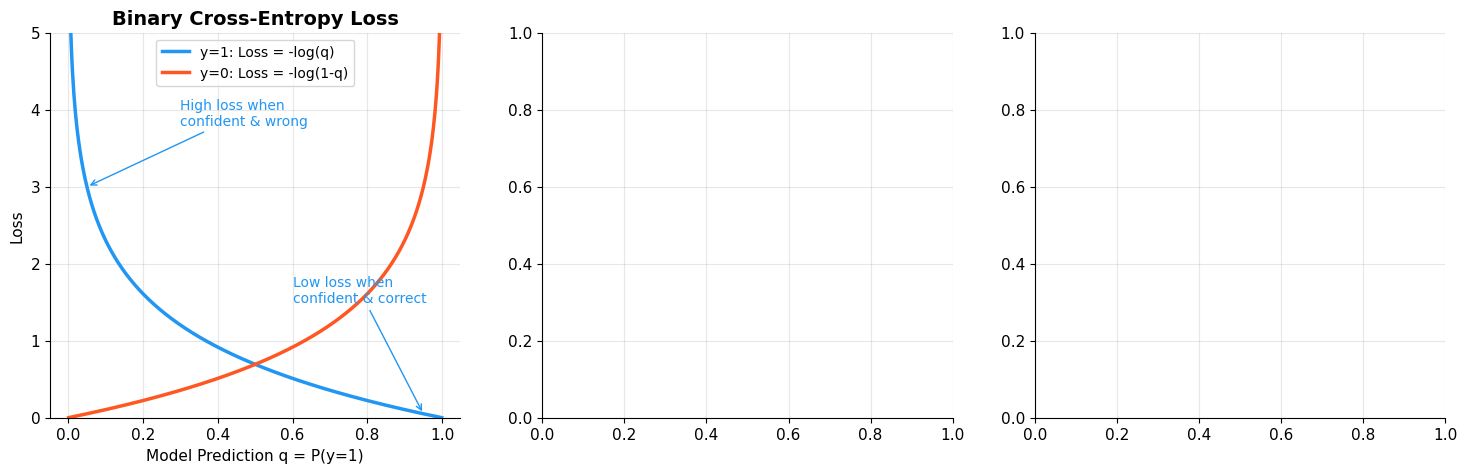

In [10]:
# Cross-Entropy & KL Divergence — Detailed Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Left: Cross-Entropy as a loss ---
ax = axes[0]
q_values = np.linspace(0.001, 0.999, 500)

# True label y=1: CE = -log(q)
ce_y1 = -np.log(q_values)
# True label y=0: CE = -log(1-q)
ce_y0 = -np.log(1 - q_values)

ax.plot(q_values, ce_y1, linewidth=2.5, color=COLORS[0], label='y=1: Loss = -log(q)')
ax.plot(q_values, ce_y0, linewidth=2.5, color=COLORS[1], label='y=0: Loss = -log(1-q)')
ax.set_xlabel('Model Prediction q = P(y=1)', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Binary Cross-Entropy Loss', fontweight='bold')
ax.set_ylim(0, 5)
ax.legend(fontsize=10)
ax.annotate('Low loss when\nconfident & correct', xy=(0.95, 0.05), xytext=(0.6, 1.5),
            arrowprops=dict(arrowstyle='->', color=COLORS[0]),
            fontsize=10, color=COLORS[0])
ax.annotate('High loss when\nconfident & wrong', xy=(0.05, 3.0), xytext=(0.3, 3.8),
            arrowprops=dict(arrowstyle='->', color=COLORS[0]),
            fontsize=10, color=COLORS[0])

# --- Middle: KL Divergence asymmetry ---
ax = axes[1]
x_range = np.linspace(-5, 8, 1000)

# P is a mixture of two Gaussians
P = 0.5 * stats.norm.pdf(x_range, -1, 0.8) + 0.5 * stats.norm.pdf(x_range, 3, 0.8)
P = P / np.trapz(P, x_range)  # Normalize

# Q_forward: mean-seeking (wide Gaussian covering both modes)
Q_fwd = stats.norm.pdf(x_range, 1.0, 2.5)
# Q_reverse: mode-seeking (focuses on one mode)
Q_rev = stats.norm.pdf(x_range, -1, 0.9)

ax.plot(x_range, P, linewidth=3, color='black', label='P (true)', linestyle='-')
ax.fill_between(x_range, P, alpha=0.15, color='black')
ax.plot(x_range, Q_fwd, linewidth=2, color=COLORS[0], label='Q (forward KL)', linestyle='--')
ax.plot(x_range, Q_rev, linewidth=2, color=COLORS[1], label='Q (reverse KL)', linestyle='--')
ax.set_title('KL Divergence: Forward vs Reverse', fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.legend(fontsize=10)
ax.text(1, 0.2, 'Mean-seeking\n(covers all of P)', ha='center', color=COLORS[0], fontsize=10, fontweight='bold')
ax.text(-1, 0.35, 'Mode-seeking\n(picks one peak)', ha='center', color=COLORS[1], fontsize=10, fontweight='bold')

# --- Right: Relationship H, CE, KL ---
ax = axes[2]
categories = ['H(P)\nEntropy', 'D_KL(P||Q)\nKL Divergence', 'H(P,Q)\nCross-Entropy']
# Example values
H_P = 1.0
D_KL = 0.6
H_PQ = H_P + D_KL
values = [H_P, D_KL, H_PQ]
bar_colors = [COLORS[2], COLORS[1], COLORS[3]]

bars = ax.bar(categories, values, color=bar_colors, alpha=0.8, edgecolor='white', linewidth=2, width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.1f}', ha='center', fontweight='bold', fontsize=13)

# Show the relationship
ax.annotate('', xy=(2, H_P), xytext=(0, H_P),
            arrowprops=dict(arrowstyle='-', color='gray', linestyle='dashed', linewidth=1.5))
ax.set_title('H(P,Q) = H(P) + D_KL(P||Q)', fontweight='bold')
ax.set_ylabel('Bits')
ax.set_ylim(0, 2.2)

plt.tight_layout()
plt.show()

---
# 5. 🎯 Loss Functions

The loss function is the **objective** that the optimizer minimizes during training. It quantifies *how wrong* the model's predictions are. Choosing the right loss function is as important as choosing the right model architecture.

---

## 5.1 Regression Losses

### Mean Squared Error (MSE) / L2 Loss

$$\mathcal{L}_{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**Properties:**
- Differentiable everywhere → smooth gradients
- Heavily penalizes large errors (quadratic penalty)
- Sensitive to outliers
- Gradient: $\nabla_{\hat{y}} \mathcal{L} = \frac{2}{n}(\hat{y} - y)$ — gradient magnitude is proportional to error

> **Probabilistic interpretation:** MSE is equivalent to maximizing the likelihood of a Gaussian noise model: $y = \hat{y} + \epsilon$, where $\epsilon \sim \mathcal{N}(0, \sigma^2)$

### Mean Absolute Error (MAE) / L1 Loss

$$\mathcal{L}_{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

**Properties:**
- Robust to outliers (linear penalty)
- Not differentiable at 0 → gradient is always ±1 (constant)
- Can be unstable near the minimum

> **Probabilistic interpretation:** MAE assumes Laplace-distributed noise.

### Huber Loss (Smooth L1)

The **best of both worlds** — quadratic for small errors, linear for large ones:

$$\mathcal{L}_{Huber} = \begin{cases} \frac{1}{2}(y - \hat{y})^2 & \text{if } |y - \hat{y}| \leq \delta \\ \delta \cdot |y - \hat{y}| - \frac{1}{2}\delta^2 & \text{otherwise} \end{cases}$$

- Differentiable everywhere
- Robust to outliers (like MAE)
- Smooth gradients near 0 (like MSE)
- $\delta$ controls the transition point

In [ ]:
# Regression Loss Functions — Comparison
errors = np.linspace(-4, 4, 1000)

# Compute losses
mse = errors ** 2
mae = np.abs(errors)

delta = 1.0
huber = np.where(np.abs(errors) <= delta,
                 0.5 * errors**2,
                 delta * np.abs(errors) - 0.5 * delta**2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Left: Loss comparison ---
ax = axes[0]
ax.plot(errors, mse, linewidth=2.5, color=COLORS[0], label='MSE (L2)')
ax.plot(errors, mae, linewidth=2.5, color=COLORS[1], label='MAE (L1)')
ax.plot(errors, huber, linewidth=2.5, color=COLORS[2], label=f'Huber (δ={delta})', linestyle='--')
ax.set_xlabel('Error (y - ŷ)', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Loss Functions Compared', fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 8)

# --- Middle: Gradient comparison ---
ax = axes[1]
grad_mse = 2 * errors
grad_mae = np.sign(errors)
grad_huber = np.where(np.abs(errors) <= delta, errors, delta * np.sign(errors))

ax.plot(errors, grad_mse, linewidth=2.5, color=COLORS[0], label='MSE gradient: 2e')
ax.plot(errors, grad_mae, linewidth=2.5, color=COLORS[1], label='MAE gradient: sign(e)')
ax.plot(errors, grad_huber, linewidth=2.5, color=COLORS[2], label='Huber gradient', linestyle='--')
ax.set_xlabel('Error (y - ŷ)', fontsize=12)
ax.set_ylabel('Gradient', fontsize=12)
ax.set_title('Gradients — How Hard They Push', fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0, color='gray', linewidth=0.5)

# --- Right: Effect of outliers ---
ax = axes[2]
np.random.seed(42)
x_data = np.linspace(0, 10, 30)
y_clean = 2 * x_data + 1 + np.random.normal(0, 1.5, 30)
y_outlier = y_clean.copy()
y_outlier[25] = 40  # Add outlier
y_outlier[27] = -10  # Add outlier

# Fit with MSE vs MAE (using polyfit as proxy)
coef_mse = np.polyfit(x_data, y_outlier, 1)  # MSE-based fit

# Simple MAE-based fit via median regression (approximate)
from scipy.optimize import minimize
def mae_loss(params):
    return np.mean(np.abs(y_outlier - (params[0] * x_data + params[1])))
result = minimize(mae_loss, [2, 1])
coef_mae = result.x

ax.scatter(x_data, y_outlier, color='#333', s=40, zorder=5, label='Data (with outliers)')
ax.scatter(x_data[[25, 27]], y_outlier[[25, 27]], color='red', s=100, zorder=6,
           marker='X', label='Outliers')
x_fit = np.linspace(0, 10, 100)
ax.plot(x_fit, coef_mse[0]*x_fit + coef_mse[1], linewidth=2.5, color=COLORS[0],
        label=f'MSE fit (slope={coef_mse[0]:.2f})')
ax.plot(x_fit, coef_mae[0]*x_fit + coef_mae[1], linewidth=2.5, color=COLORS[1],
        label=f'MAE fit (slope={coef_mae[0]:.2f})', linestyle='--')
ax.plot(x_fit, 2*x_fit + 1, linewidth=1.5, color='gray', linestyle=':', label='True line')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('MSE vs MAE: Outlier Robustness', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('Key Takeaway:')
print('  MSE: Pulled toward outliers (slope distorted)')
print('  MAE: More robust to outliers (closer to true line)')
print('  Huber: Best of both — smooth near zero, robust to outliers')

## 5.2 Classification Losses

### Binary Cross-Entropy (BCE) / Log Loss

For binary classification where $y \in \{0, 1\}$ and $\hat{y} = P(y=1)$:

$$\mathcal{L}_{BCE} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

**Why this works:**
- When $y=1$: loss = $-\log(\hat{y})$ → penalizes when model predicts low probability for actual positive
- When $y=0$: loss = $-\log(1-\hat{y})$ → penalizes when model predicts high probability for actual negative
- Gradient: $\nabla = \hat{y} - y$ — elegant and simple!

### Categorical Cross-Entropy

Generalization to $C$ classes with one-hot encoded labels:

$$\mathcal{L}_{CE} = -\sum_{c=1}^{C} y_c \log(\hat{y}_c)$$

Since $y$ is one-hot (only one $y_c = 1$), this simplifies to:

$$\mathcal{L}_{CE} = -\log(\hat{y}_{\text{true class}})$$

> The loss is just the negative log probability assigned to the correct class!

### Hinge Loss (SVM Loss)

For binary classification with $y \in \{-1, +1\}$:

$$\mathcal{L}_{Hinge} = \max(0, 1 - y \cdot \hat{y})$$

- No penalty when $y \cdot \hat{y} \geq 1$ (correct and confident)
- Linear penalty otherwise
- Creates a **margin** — encourages confident correct predictions
- Foundation of Support Vector Machines (SVMs)

In [ ]:
# Classification Loss Functions — Detailed Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Left: Binary Cross-Entropy ---
ax = axes[0]
y_pred = np.linspace(0.001, 0.999, 500)

# When y=1
bce_y1 = -np.log(y_pred)
# When y=0
bce_y0 = -np.log(1 - y_pred)

ax.plot(y_pred, bce_y1, linewidth=2.5, color=COLORS[0], label='True label y=1')
ax.plot(y_pred, bce_y0, linewidth=2.5, color=COLORS[1], label='True label y=0')
ax.set_xlabel('Model Prediction P(y=1)', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Binary Cross-Entropy', fontweight='bold')
ax.set_ylim(0, 5)
ax.legend(fontsize=11)

# Annotate key insight
ax.annotate('Huge penalty for\nconfident wrong prediction!', xy=(0.05, 3),
            xytext=(0.3, 4), arrowprops=dict(arrowstyle='->', color=COLORS[0]),
            fontsize=10, fontweight='bold', color=COLORS[0])

# --- Middle: Categorical CE with softmax output ---
ax = axes[1]
# Show how loss changes as confidence in correct class varies
confidence = np.linspace(0.01, 0.99, 500)
loss_ce = -np.log(confidence)

# Compare with MSE loss for classification
loss_mse = (1 - confidence) ** 2

ax.plot(confidence, loss_ce, linewidth=2.5, color=COLORS[0], label='Cross-Entropy: -log(p_correct)')
ax.plot(confidence, loss_mse, linewidth=2.5, color=COLORS[1], label='MSE: (1 - p_correct)²', linestyle='--')
ax.set_xlabel('Confidence in Correct Class', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Why CE > MSE for Classification', fontweight='bold')
ax.set_ylim(0, 5)
ax.legend(fontsize=10)
ax.annotate('CE has much stronger\ngradient at low confidence\n→ faster learning!', xy=(0.1, 2.3),
            xytext=(0.35, 3.5), arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, fontweight='bold')

# --- Right: Hinge Loss ---
ax = axes[2]
raw_score = np.linspace(-3, 3, 500)

# y=+1: hinge = max(0, 1 - score)
hinge = np.maximum(0, 1 - raw_score)
# Zero-one loss for comparison
zero_one = (raw_score < 0).astype(float)
# Logistic loss for comparison
log_loss = np.log(1 + np.exp(-raw_score)) / np.log(2)

ax.plot(raw_score, hinge, linewidth=2.5, color=COLORS[0], label='Hinge: max(0, 1-yŷ)')
ax.plot(raw_score, zero_one, linewidth=2.5, color=COLORS[2], label='0-1 Loss (ideal)', linestyle=':')
ax.plot(raw_score, log_loss, linewidth=2.5, color=COLORS[1], label='Logistic Loss', linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='-')
ax.axvline(1, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel('y · ŷ (margin)', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Hinge Loss & Margin', fontweight='bold')
ax.legend(fontsize=10)
ax.annotate('Margin\nboundary', xy=(1, 0), xytext=(1.8, 1.5),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10, color='gray')

plt.tight_layout()
plt.show()

print('\n📊 Summary Table — Loss Functions for Classification:')
print('┌──────────────────────┬────────────────────┬──────────────┬──────────────┐')
print('│ Loss Function        │ Formula            │ Output Range │ Used In      │')
print('├──────────────────────┼────────────────────┼──────────────┼──────────────┤')
print('│ Binary Cross-Entropy │ -y·log(ŷ)-(1-y)·  │ [0, ∞)       │ Logistic Reg │')
print('│                      │  log(1-ŷ)         │              │ Neural Nets  │')
print('│ Categorical CE       │ -Σ yc·log(ŷc)     │ [0, ∞)       │ Multiclass   │')
print('│ Hinge Loss           │ max(0, 1-y·ŷ)     │ [0, ∞)       │ SVM          │')
print('│ 0-1 Loss             │ 𝟙[y≠ŷ]            │ {0, 1}       │ Theoretical  │')
print('└──────────────────────┴────────────────────┴──────────────┴──────────────┘')

---
# 6. ⚡ Activation Functions & Their Derivatives

Activation functions introduce **nonlinearity** into neural networks. Without them, stacking layers would just produce another linear function. They are the reason deep networks can approximate any continuous function (Universal Approximation Theorem).

---

## 6.1 Sigmoid (Logistic Function)

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Derivative:** $\sigma'(z) = \sigma(z)(1 - \sigma(z))$

**Properties:**
- Output range: $(0, 1)$ — interpretable as probability
- Smooth and differentiable everywhere
- ⚠️ **Vanishing gradients:** $\sigma'(z)$ is at most 0.25 (at $z=0$). In deep networks, gradients shrink exponentially through layers.
- ⚠️ **Not zero-centered:** Outputs are always positive → zig-zagging gradients during optimization

## 6.2 Tanh (Hyperbolic Tangent)

$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}} = 2\sigma(2z) - 1$$

**Derivative:** $\tanh'(z) = 1 - \tanh^2(z)$

**Properties:**
- Output range: $(-1, 1)$ — **zero-centered** ✅
- Stronger gradients than sigmoid (max derivative = 1)
- Still suffers from vanishing gradients for large $|z|$

## 6.3 ReLU (Rectified Linear Unit)

$$\text{ReLU}(z) = \max(0, z)$$

**Derivative:** $\text{ReLU}'(z) = \begin{cases} 1 & z > 0 \\ 0 & z < 0 \end{cases}$

**Properties:**
- **No vanishing gradient** for positive inputs ✅
- Computationally efficient (just a threshold)
- Introduces sparsity (many neurons output exactly 0)
- ⚠️ **Dying ReLU problem:** If a neuron's input is always negative, gradient = 0 → neuron never updates

### Variants:
- **Leaky ReLU:** $f(z) = \max(\alpha z, z)$ where $\alpha \approx 0.01$ — fixes dying ReLU
- **GELU:** $f(z) = z \cdot \Phi(z)$ — smooth approximation, used in Transformers
- **SiLU / Swish:** $f(z) = z \cdot \sigma(z)$ — self-gated, used in modern architectures

## 6.4 Softmax

Converts a vector of raw scores (logits) into a probability distribution:

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

**Properties:**
- Outputs sum to 1 (valid probability distribution)
- Each output $\in (0, 1)$
- Amplifies differences: the largest logit gets the most probability mass
- **Temperature scaling:** $\text{softmax}(z_i / T)$ — lower $T$ → sharper, higher $T$ → flatter

In [ ]:
# Activation Functions — Comprehensive Visualization
z = np.linspace(-6, 6, 1000)

# Define activations and their derivatives
activations = {
    'Sigmoid': {
        'f': 1 / (1 + np.exp(-z)),
        'df': (1 / (1 + np.exp(-z))) * (1 - 1 / (1 + np.exp(-z))),
        'color': COLORS[0],
    },
    'Tanh': {
        'f': np.tanh(z),
        'df': 1 - np.tanh(z)**2,
        'color': COLORS[1],
    },
    'ReLU': {
        'f': np.maximum(0, z),
        'df': (z > 0).astype(float),
        'color': COLORS[2],
    },
    'Leaky ReLU': {
        'f': np.where(z > 0, z, 0.1 * z),
        'df': np.where(z > 0, 1, 0.1),
        'color': COLORS[3],
    },
    'GELU': {
        'f': z * stats.norm.cdf(z),
        'df': stats.norm.cdf(z) + z * stats.norm.pdf(z),
        'color': COLORS[4],
    },
    'SiLU (Swish)': {
        'f': z * (1 / (1 + np.exp(-z))),
        'df': (1 / (1 + np.exp(-z))) + z * (1 / (1 + np.exp(-z))) * (1 - 1 / (1 + np.exp(-z))),
        'color': COLORS[5],
    },
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (name, data) in enumerate(activations.items()):
    row, col = divmod(idx, 3)
    ax = axes[row][col]
    
    ax.plot(z, data['f'], linewidth=2.5, color=data['color'], label=f'{name}')
    ax.plot(z, data['df'], linewidth=2, color=data['color'], label=f"{name}' (derivative)",
            linestyle='--', alpha=0.7)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_title(name, fontweight='bold', fontsize=14)
    ax.legend(fontsize=10)
    ax.set_xlabel('z')
    ax.set_ylabel('Output')
    if name in ['Sigmoid', 'Tanh']:
        ax.set_ylim(-1.5, 1.5)
    elif name == 'ReLU' or name == 'Leaky ReLU':
        ax.set_ylim(-2, 6)

plt.suptitle('Activation Functions and Their Derivatives', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Softmax — Temperature Scaling Demo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw logits
logits = np.array([2.0, 1.0, 0.5, 0.1, -0.5])
classes = ['Cat', 'Dog', 'Bird', 'Fish', 'Snake']

temperatures = [0.3, 1.0, 5.0]
titles = ['T=0.3 (Sharp/Confident)', 'T=1.0 (Standard)', 'T=5.0 (Soft/Uncertain)']

for ax, T, title in zip(axes, temperatures, titles):
    scaled = logits / T
    softmax_probs = np.exp(scaled) / np.sum(np.exp(scaled))
    
    bars = ax.barh(classes, softmax_probs, color=COLORS[:5], edgecolor='white', linewidth=2)
    ax.set_xlim(0, 1)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('Probability')
    
    # Add value labels
    for bar, prob in zip(bars, softmax_probs):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                f'{prob:.3f}', va='center', fontweight='bold', fontsize=11)
    
    # Show entropy
    H = -np.sum(softmax_probs * np.log2(softmax_probs + 1e-10))
    ax.text(0.95, 0.05, f'H = {H:.2f} bits', transform=ax.transAxes,
            ha='right', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f'Softmax Temperature Scaling — Logits: {list(logits)}',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print('🔑 Key Insight:')
print('  • Low temperature → model becomes more confident (picks one class)')
print('  • High temperature → model becomes more uncertain (spreads probability)')
print('  • T→0: argmax (hard selection), T→∞: uniform distribution')
print('  • Used in: Knowledge distillation, LLM sampling, exploration vs exploitation')

---
# 7. 📏 Norms & Regularization

Norms measure the "size" of vectors and matrices. In ML, they're used to penalize model complexity and prevent overfitting.

---

## 7.1 Vector Norms

### L1 Norm (Manhattan Distance)
$$\|\mathbf{x}\|_1 = \sum_{i=1}^{n} |x_i|$$

### L2 Norm (Euclidean Distance)
$$\|\mathbf{x}\|_2 = \sqrt{\sum_{i=1}^{n} x_i^2}$$

### Lp Norm (General)
$$\|\mathbf{x}\|_p = \left(\sum_{i=1}^{n} |x_i|^p\right)^{1/p}$$

### L∞ Norm (Max Norm)
$$\|\mathbf{x}\|_\infty = \max_i |x_i|$$

## 7.2 Regularization

Adding a norm-based penalty to the loss function to control model complexity:

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{data}} + \lambda \cdot \mathcal{R}(\mathbf{w})$$

| Regularizer | Penalty $\mathcal{R}$ | Effect | Name |
|-----------|---------|--------|------|
| **L1** | $\sum \|w_i\|$ | Drives weights to **exactly zero** → feature selection / sparsity | Lasso |
| **L2** | $\sum w_i^2$ | Drives weights toward **small values** (but not zero) | Ridge / Weight Decay |
| **Elastic Net** | $\alpha\sum\|w_i\| + (1-\alpha)\sum w_i^2$ | Combination of L1 and L2 | Elastic Net |

> **Bayesian Interpretation:**
> - L2 regularization = Gaussian prior on weights: $w \sim \mathcal{N}(0, \frac{1}{2\lambda})$
> - L1 regularization = Laplace prior on weights: $w \sim \text{Laplace}(0, \frac{1}{\lambda})$
> - MAP estimation with these priors gives you Ridge/Lasso regression!

In [ ]:
# Norms & Regularization — Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# --- Left: Unit circles for different norms ---
ax = axes[0]
theta = np.linspace(0, 2*np.pi, 1000)

norms = {
    'L1 (diamond)': (0.5, lambda t: (np.abs(np.cos(t)) + np.abs(np.sin(t)))),
    'L2 (circle)': (1, None),  # Special case
    'L∞ (square)': (2, lambda t: np.maximum(np.abs(np.cos(t)), np.abs(np.sin(t)))),
}

# L1 norm unit ball
t = np.linspace(0, 2*np.pi, 1000)
r_l1 = 1 / (np.abs(np.cos(t)) + np.abs(np.sin(t)))
ax.plot(r_l1 * np.cos(t), r_l1 * np.sin(t), linewidth=2.5, color=COLORS[0], label='L1 (||x||₁ = 1)')

# L2 norm unit ball
ax.plot(np.cos(t), np.sin(t), linewidth=2.5, color=COLORS[1], label='L2 (||x||₂ = 1)')

# L∞ norm unit ball
r_linf = 1 / np.maximum(np.abs(np.cos(t)), np.abs(np.sin(t)))
ax.plot(r_linf * np.cos(t), r_linf * np.sin(t), linewidth=2.5, color=COLORS[2], label='L∞ (||x||∞ = 1)')

# Lp=0.5 for illustration
p = 0.5
r_lp = 1 / (np.abs(np.cos(t))**p + np.abs(np.sin(t))**p)**(1/p)
ax.plot(r_lp * np.cos(t), r_lp * np.sin(t), linewidth=2, color=COLORS[3], linestyle='--', label='Lp=0.5')

ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.axhline(0, color='gray', linewidth=0.3)
ax.axvline(0, color='gray', linewidth=0.3)
ax.set_title('Unit Balls for Different Norms', fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlabel('w₁'); ax.set_ylabel('w₂')

# --- Middle: L1 vs L2 regularization effect on weights ---
ax = axes[1]
np.random.seed(42)
n_weights = 20
true_weights = np.array([3, -2, 0, 0, 1.5, 0, 0, -0.5, 0, 0,
                         0, 0.8, 0, 0, 0, -1.2, 0, 0, 0, 0])

# Simulate effect of regularization (simplified)
lambda_val = 0.5
# L1: soft-thresholding (drives small weights to 0)
w_l1 = np.sign(true_weights) * np.maximum(np.abs(true_weights) - lambda_val, 0)
# L2: shrinkage (scales all weights toward 0)
w_l2 = true_weights / (1 + lambda_val)

x_idx = np.arange(n_weights)
width = 0.25
ax.bar(x_idx - width, true_weights, width, label='Original', color=COLORS[4], alpha=0.6)
ax.bar(x_idx, w_l1, width, label='L1 (Lasso)', color=COLORS[0], alpha=0.8)
ax.bar(x_idx + width, w_l2, width, label='L2 (Ridge)', color=COLORS[1], alpha=0.8)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Weight Index')
ax.set_ylabel('Weight Value')
ax.set_title('L1 → Sparsity, L2 → Shrinkage', fontweight='bold')
ax.legend(fontsize=10)

# --- Right: Regularization path ---
ax = axes[2]
lambdas = np.linspace(0, 3, 100)
# Track a few weights across regularization strengths
weights_to_track = [0, 1, 4, 7, 11, 15]  # indices

for i, idx in enumerate(weights_to_track):
    w_orig = true_weights[idx]
    # L2 regularization path
    path = w_orig / (1 + lambdas)
    ax.plot(lambdas, path, linewidth=2, color=COLORS[i % len(COLORS)],
            label=f'w[{idx}]={w_orig}')

ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel('λ (regularization strength)', fontsize=11)
ax.set_ylabel('Weight value', fontsize=11)
ax.set_title('L2 Regularization Path', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('\n🔑 Key Insights:')
print('  L1 (Lasso): Diamond-shaped constraint → solutions land on axes → SPARSE weights')
print('  L2 (Ridge): Circular constraint → shrinks all weights evenly → SMALL weights')
print('  The L1 unit ball has "corners" on the axes — that\'s why it produces exact zeros!')

In [ ]:
# L1 vs L2 — Why L1 produces sparsity (Geometric Intuition)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_idx, (norm_name, color) in enumerate([('L1 (Lasso)', COLORS[0]), ('L2 (Ridge)', COLORS[1])]):
    ax = axes[ax_idx]
    
    # Loss contours (elliptical — representing MSE loss landscape)
    w1 = np.linspace(-3, 3, 300)
    w2 = np.linspace(-3, 3, 300)
    W1, W2 = np.meshgrid(w1, w2)
    
    # Elliptical loss centered at (2, 1) — the unconstrained optimum
    Loss = 0.5 * (W1 - 2)**2 + 2 * (W2 - 1)**2
    
    ax.contour(W1, W2, Loss, levels=15, cmap='Greys', alpha=0.4)
    ax.plot(2, 1, 'k*', markersize=15, label='Unconstrained opt.')
    
    # Draw constraint boundary
    t = np.linspace(0, 2*np.pi, 1000)
    
    if ax_idx == 0:  # L1
        budget = 1.2
        r = budget / (np.abs(np.cos(t)) + np.abs(np.sin(t)))
        x_c, y_c = r * np.cos(t), r * np.sin(t)
        ax.fill(x_c, y_c, alpha=0.2, color=color)
        ax.plot(x_c, y_c, linewidth=2.5, color=color, label='L1 constraint')
        # Intersection point (on axis!)
        ax.plot(1.2, 0, 'ro', markersize=12, zorder=10, label='Solution (sparse!)')
        ax.annotate('w₂ = 0!\n(Feature eliminated)', xy=(1.2, 0),
                    xytext=(2, -1.5), fontsize=11, fontweight='bold', color='red',
                    arrowprops=dict(arrowstyle='->', color='red'))
    else:  # L2
        budget = 1.2
        x_c = budget * np.cos(t)
        y_c = budget * np.sin(t)
        ax.fill(x_c, y_c, alpha=0.2, color=color)
        ax.plot(x_c, y_c, linewidth=2.5, color=color, label='L2 constraint')
        # Intersection point (NOT on axis)
        ax.plot(1.1, 0.5, 'ro', markersize=12, zorder=10, label='Solution (dense)')
        ax.annotate('Both weights\nremain non-zero', xy=(1.1, 0.5),
                    xytext=(2, -1.5), fontsize=11, fontweight='bold', color='red',
                    arrowprops=dict(arrowstyle='->', color='red'))
    
    ax.set_xlim(-2.5, 3)
    ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', linewidth=0.3)
    ax.axvline(0, color='gray', linewidth=0.3)
    ax.set_xlabel('w₁', fontsize=12)
    ax.set_ylabel('w₂', fontsize=12)
    ax.set_title(f'{norm_name} — Geometric View', fontweight='bold', fontsize=14)
    ax.legend(fontsize=10, loc='upper left')

plt.suptitle('Why L1 Produces Sparse Solutions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('The loss contours (ellipses) "touch" the L1 diamond at a corner → ON an axis → sparse!')
print('The same contours touch the L2 circle at a smooth point → NOT on an axis → dense!')

---
# 📋 Part 1 — Summary & Cheat Sheet

## Quick Reference Table

| Concept | Key Formula | ML Application |
|---------|------------|----------------|
| **Bayes' Theorem** | $P(\theta|D) = \frac{P(D|\theta)P(\theta)}{P(D)}$ | Posterior inference, Bayesian NNs |
| **Gaussian** | $f(x) = \frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}$ | Noise model, VAEs, weight init |
| **Cross-Entropy** | $H(P,Q) = -\sum P(x)\log Q(x)$ | Classification loss function |
| **KL Divergence** | $D_{KL}(P\|Q) = \sum P(x)\log\frac{P(x)}{Q(x)}$ | VAE loss (ELBO), distribution matching |
| **MSE Loss** | $\frac{1}{n}\sum(y-\hat{y})^2$ | Regression (assumes Gaussian noise) |
| **Sigmoid** | $\sigma(z) = \frac{1}{1+e^{-z}}$ | Binary classification output |
| **Softmax** | $\frac{e^{z_i}}{\sum e^{z_j}}$ | Multi-class classification output |
| **L1 Regularization** | $\lambda\sum|w_i|$ | Feature selection, sparsity |
| **L2 Regularization** | $\lambda\sum w_i^2$ | Weight decay, prevent overfitting |

## What's Coming in Part 2 (Deep Dive)

- 🔢 **Linear Algebra for ML** — Eigendecomposition, SVD, PCA, matrix calculus
- 📐 **Calculus & Optimization** — Gradient descent, backpropagation, Adam, learning rate schedules
- 🧮 **Maximum Likelihood & MAP Estimation** — Deriving loss functions from first principles
- 🎰 **Sampling Methods** — Monte Carlo, MCMC, reparameterization trick
- 🌊 **Variational Inference** — ELBO, VAEs, the full derivation
- 📊 **Hypothesis Testing & Confidence Intervals** — Statistical significance in ML experiments

---
*Created as part of the NanoGPT project — building understanding from the ground up.*